# Step 1: Raw data loading and parsing

We extract CWRU bearing metadata from raw dataset folder structure, then loads and parses a bearing MatLab data file (.mat) into pd.DataFrame, and saves as csv file.

The resulting data is called the 'parsed' data.

In [1]:
# Load the "autoreload" extension so that code can change
%load_ext autoreload
# Always reload modules so that as you change code in src, it gets loaded
%autoreload 2

import os
from copy import deepcopy
import json
import yaml
import re

import numpy as np
import pandas as pd
from scipy.io import loadmat

import matplotlib.pyplot as plt

from data_parse import get_bearing_metadatas, load_parse_mat_to_csv, parse_dataset, RAW_DATA_DIR
from blob_utils import get_container_client, download_blob, download_container, save_file_to_blob, save_folder_to_container

## Extract metadata from raw data folder structure

In [2]:
metadatas = get_bearing_metadatas(output_dir='./')

In [3]:
metadatas[:5]

[{'raw_data_path': './data/Normal/99_Normal_2.mat',
  'cycle_id': '99',
  'fault_label': 'N',
  'motor_load_hp': '2',
  'sampling_freq_khz': 12.0,
  'fault_type': 'N',
  'fault_location': None,
  'fault_diameter': None,
  'OR_position': None},
 {'raw_data_path': './data/Normal/98_Normal_1.mat',
  'cycle_id': '98',
  'fault_label': 'N',
  'motor_load_hp': '1',
  'sampling_freq_khz': 12.0,
  'fault_type': 'N',
  'fault_location': None,
  'fault_diameter': None,
  'OR_position': None},
 {'raw_data_path': './data/Normal/97_Normal_0.mat',
  'cycle_id': '97',
  'fault_label': 'N',
  'motor_load_hp': '0',
  'sampling_freq_khz': 12.0,
  'fault_type': 'N',
  'fault_location': None,
  'fault_diameter': None,
  'OR_position': None},
 {'raw_data_path': './data/Normal/100_Normal_3.mat',
  'cycle_id': '100',
  'fault_label': 'N',
  'motor_load_hp': '3',
  'sampling_freq_khz': 12.0,
  'fault_type': 'N',
  'fault_location': None,
  'fault_diameter': None,
  'OR_position': None},
 {'raw_data_path': './

In [4]:
# with open('.credentials/azure_blob.yml', 'r') as f:
#     creds = yaml.load(f, yaml.SafeLoader)

In [7]:
# tar raw data for upload to Azure blob
# !tar -zcvf data_raw.tar.gz ./data

## Data loading and parsing

Extract bearing metadata, parse matlab files to csv files

In [8]:
parsed_metadatas = parse_dataset()

In [9]:
parsed_metadatas[:5]

[{'raw_data_path': './data/Normal/99_Normal_2.mat',
  'cycle_id': '99',
  'fault_label': 'N',
  'motor_load_hp': '2',
  'sampling_freq_khz': 12.0,
  'fault_type': 'N',
  'fault_location': None,
  'fault_diameter': None,
  'OR_position': None,
  'rpm': 1750,
  'df_length': 485063,
  'df_columns': ['DE_time', 'FE_time', 'cycle_id'],
  'parsed_data_path': './data_parsed/csv/99.csv'},
 {'raw_data_path': './data/Normal/98_Normal_1.mat',
  'cycle_id': '98',
  'fault_label': 'N',
  'motor_load_hp': '1',
  'sampling_freq_khz': 12.0,
  'fault_type': 'N',
  'fault_location': None,
  'fault_diameter': None,
  'OR_position': None,
  'rpm': 1772,
  'df_length': 483903,
  'df_columns': ['DE_time', 'FE_time', 'cycle_id'],
  'parsed_data_path': './data_parsed/csv/98.csv'},
 {'raw_data_path': './data/Normal/97_Normal_0.mat',
  'cycle_id': '97',
  'fault_label': 'N',
  'motor_load_hp': '0',
  'sampling_freq_khz': 12.0,
  'fault_type': 'N',
  'fault_location': None,
  'fault_diameter': None,
  'OR_positi

## Quick metadata statistics

`'fault_diameter': '028'` bearings have no `FE_time` column in data. Do not use them

In [12]:
[dict_['fault_diameter'] for dict_ in parsed_metadatas
 if len(dict_['df_columns']) < 3]

['028', '028', '028', '028', '028', '028', '028', '028']

In [13]:
{len(dict_['df_columns']) for dict_ in parsed_metadatas
 if dict_['fault_diameter'] == '007'}

{3, 4}

In [14]:
{len(dict_['df_columns']) for dict_ in parsed_metadatas
 if dict_['fault_diameter'] == '028'}

{2}

In [15]:
set([dict_['motor_load_hp'] for dict_ in parsed_metadatas])

{'0', '1', '2', '3'}

In [70]:
set([dict_['OR_position'] for dict_ in parsed_metadatas])

{'@12', '@3', '@6', None}

Normal bearings appear to have different number of rows

In [16]:
normal_bearings = [bearing for bearing in parsed_metadatas
                   if bearing['fault_type'] == 'N']
[[bearing['cycle_id'], bearing['sampling_freq_khz'],
                    bearing['df_length']
 ] for bearing in normal_bearings]

[['99', 12.0, 485063],
 ['98', 12.0, 483903],
 ['97', 12.0, 243938],
 ['100', 12.0, 485643]]

In [17]:
normal_bearings

[{'raw_data_path': './data/Normal/99_Normal_2.mat',
  'cycle_id': '99',
  'fault_label': 'N',
  'motor_load_hp': '2',
  'sampling_freq_khz': 12.0,
  'fault_type': 'N',
  'fault_location': None,
  'fault_diameter': None,
  'OR_position': None,
  'rpm': 1750,
  'df_length': 485063,
  'df_columns': ['DE_time', 'FE_time', 'cycle_id'],
  'parsed_data_path': './data_parsed/csv/99.csv'},
 {'raw_data_path': './data/Normal/98_Normal_1.mat',
  'cycle_id': '98',
  'fault_label': 'N',
  'motor_load_hp': '1',
  'sampling_freq_khz': 12.0,
  'fault_type': 'N',
  'fault_location': None,
  'fault_diameter': None,
  'OR_position': None,
  'rpm': 1772,
  'df_length': 483903,
  'df_columns': ['DE_time', 'FE_time', 'cycle_id'],
  'parsed_data_path': './data_parsed/csv/98.csv'},
 {'raw_data_path': './data/Normal/97_Normal_0.mat',
  'cycle_id': '97',
  'fault_label': 'N',
  'motor_load_hp': '0',
  'sampling_freq_khz': 12.0,
  'fault_type': 'N',
  'fault_location': None,
  'fault_diameter': None,
  'OR_positi

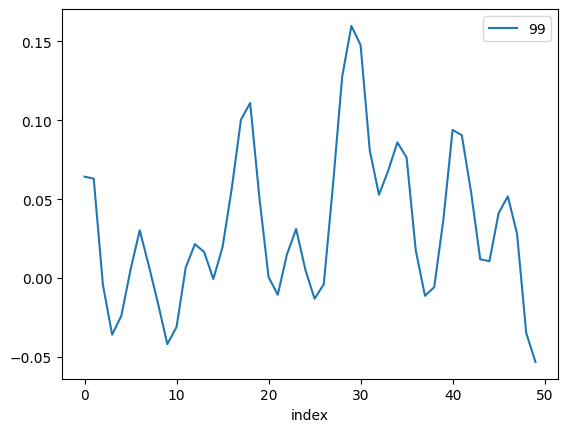

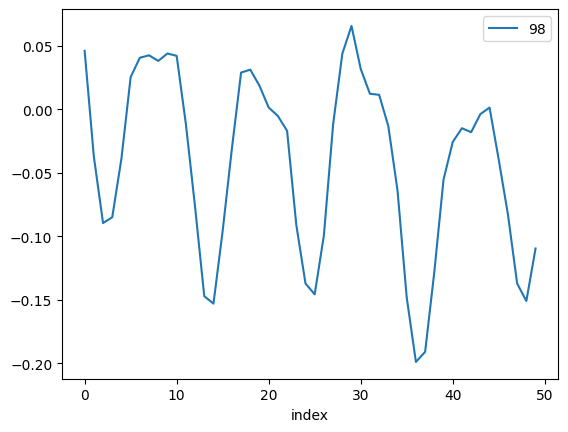

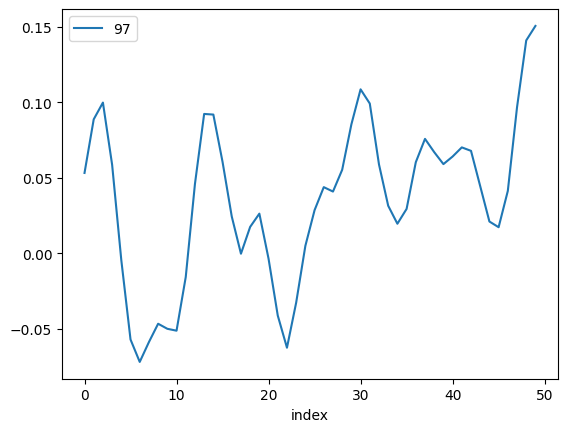

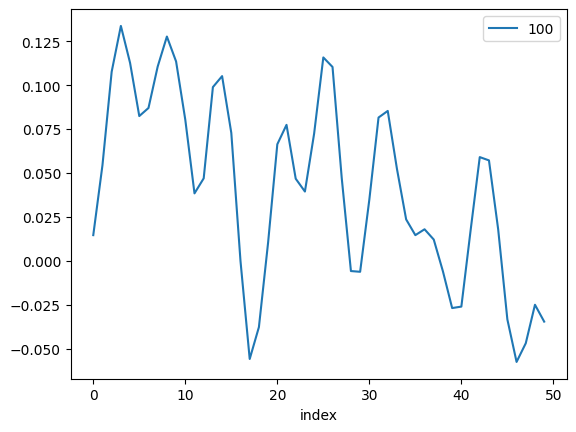

In [73]:
for normal_bearing in normal_bearings:
    pd.read_csv(normal_bearing['parsed_data_path']).set_index('index')['DE_time'][:50].plot(
        label=normal_bearing['cycle_id'])
    plt.legend()
    plt.show()